In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import jax.numpy as jnp
from jax import grad, vmap
from matplotlib.colors import LogNorm

In [2]:
import jax


optimize_mask = [True,True,False,False,True,False,False,True,False,False]
initial_guess = [1.,2.,-1.,-2.,3.,-3.,-4.,4.,-5.,-6.]
#if not traceable give true and false as static input
initial_guess = jnp.asarray(initial_guess)
optimize_mask = jnp.asarray(optimize_mask)
size_true = jnp.sum(optimize_mask)
size_false = jnp.size(optimize_mask)-size_true


arr_true = jnp.where(optimize_mask,initial_guess,jnp.nan)
arr_false = jnp.where(~optimize_mask,initial_guess,jnp.nan)

nonzero_jit = jax.jit(jnp.nonzero, static_argnames = "size")

idx_true = nonzero_jit(~jnp.isnan(arr_true),size = int(size_true))

idx_false = nonzero_jit(~jnp.isnan(arr_false),size = int(size_false))


initial_optimize_guess = arr_true[idx_true]
fixed_params = arr_false[idx_false]



def combine_params(optimized_params, fixed_params, optimize_mask):
    """
    Helper function to combine optimized and fixed parameters based on the optimize_mask.

    Parameters:
    optimized_params: jnp.ndarray - The parameters that are being optimized.
    fixed_params: jnp.ndarray - The parameters that are fixed.
    optimize_mask: jnp.ndarray - A boolean mask indicating which parameters to optimize.

    Returns:
    jnp.ndarray - A combined array of parameters.
    """
    optimize_mask = jnp.asarray(optimize_mask)
    optimized_params = jnp.asarray(optimized_params)
    fixed_params = jnp.asarray(fixed_params)


    # Generate indices for x and y where z is True and False, respectively
    optimized_params_indices = jnp.arange(len(optimized_params))    # Sequential indices for x
    fixed_params_indices = jnp.arange(len(fixed_params))    # Sequential indices for y

    # Create selection arrays based on cumulative sums to map x and y into positions of z
    optimized_params_selection = optimized_params_indices[jnp.cumsum(optimize_mask) - 1]
    fixed_params_selection = fixed_params_indices[jnp.cumsum(~optimize_mask) - 1]

    # Use jnp.where to build the final array based on the condition in z
    full_params = jnp.where(optimize_mask, optimized_params[optimized_params_selection], fixed_params[fixed_params_selection])

    return full_params


# Combine optimized and fixed parameters
full_params = combine_params(initial_optimize_guess, fixed_params, optimize_mask)

print(initial_optimize_guess)
print(fixed_params)
print(full_params)
print(optimize_mask)

[1. 2. 3. 4.]
[-1. -2. -3. -4. -5. -6.]
[ 1.  2. -1. -2.  3. -3. -4.  4. -5. -6.]
[ True  True False False  True False False  True False False]


In [3]:
def plot_img_logscale(proj_density_mat):
    """
    Plot a 2D image with a logarithmically scaled colour bar.

    Parameters:
    - proj_density_mat (numpy.ndarray): The 2D density matrix representing the density distribution projected along the z-axis.
                                    

    Returns:
    None

    This function uses Plotly matplotlib
    to create and display an image plot of the projected density with a logarithmically scaled colour bar..
    """
    plt.imshow(proj_density_mat.T, norm=colors.LogNorm(vmin=proj_density_mat.min(), vmax=proj_density_mat.max()), origin='lower')
    plt.colorbar(label='Color Scale')
    plt.show()

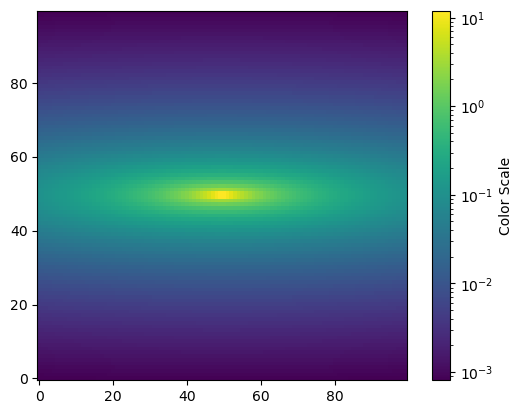

In [31]:
from JAX_Deprojection import surface_brightness as sb
from JAX_Deprojection import density_distribution as den

s = 1. 
e = 0.
p = 0.2
q = 0.6
a = 2.
b = 4.
rho0 = 0.001
size = 100
extent = 1
i = 0.
phi = 0.
theta = 0.

sb1= sb.Surface_brightness()
sb1.generate(size,extent, e, p, q, rho0, s, a, b, 0., 0., 360)
plot_img_logscale(sb1.data)

In [5]:
size = sb1.shape[0]
type(size)
size
bounds = [(0.01),(1.)]
bounds[1]

1.0

In [6]:
bounds = (0.1, 1.)

initial_params = [e,1.,q,rho0,s,a,b,i,phi,theta]
optimize_mask = [False,True,False,False,False,False,False,False,False,False]
#size = sb1.shape[0]
pred_den , res, score= sb1.deproject( bounds, initial_params, optimize_mask, 1,9,1.)
#e, p, q, rho0, s, a, b, i, phi, theta

In [7]:
print(res)

[Array(1., dtype=float32), Array(0.99652356, dtype=float32), Array(0.647688, dtype=float32), Array(0.6178963, dtype=float32), Array(0.4725927, dtype=float32), Array(0.5094191, dtype=float32), Array(0.5009177, dtype=float32), Array(0.49997064, dtype=float32)]


In [8]:
print(score)

5.6788315e-12


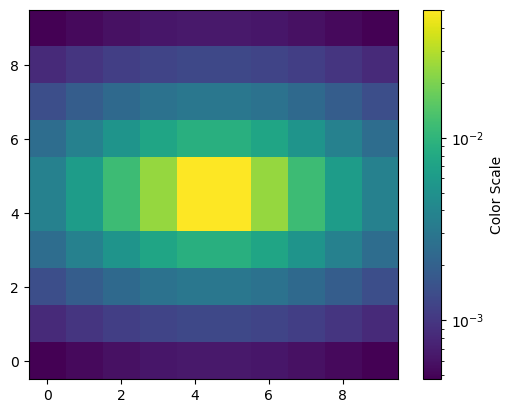

In [9]:
pred_sb = pred_den.project()
plot_img_logscale(pred_sb.data)

In [10]:
#create plot for p
# assign default values
import random


s_def = 1. 
e_def = 0.
p_def = 0.5
q_def = 0.6
a_def = 2.
b_def = 4.
rho0_def = 0.001
i_def = 0.
phi_def = 0.
theta_def = 0.

size = 100
extent = 1
extents = [-extent, extent,-extent, extent]

Optimzer route:  [Array(0.5, dtype=float32), Array(0.1, dtype=float32)]
Optimzer route:  [Array(0.5, dtype=float32), Array(0.31143168, dtype=float32), Array(0.25620013, dtype=float32), Array(0.24502908, dtype=float32), Array(0.2502041, dtype=float32), Array(0.25000665, dtype=float32), Array(0.24999999, dtype=float32), Array(0.25000003, dtype=float32)]
Optimzer route:  [Array(0.5, dtype=float32)]
Optimzer route:  [Array(0.5, dtype=float32), Array(1., dtype=float32), Array(0.8760423, dtype=float32), Array(0.7763417, dtype=float32), Array(0.7419142, dtype=float32), Array(0.7504652, dtype=float32), Array(0.750008, dtype=float32), Array(0.74999994, dtype=float32)]
Optimzer route:  [Array(0.5, dtype=float32), Array(1., dtype=float32)]


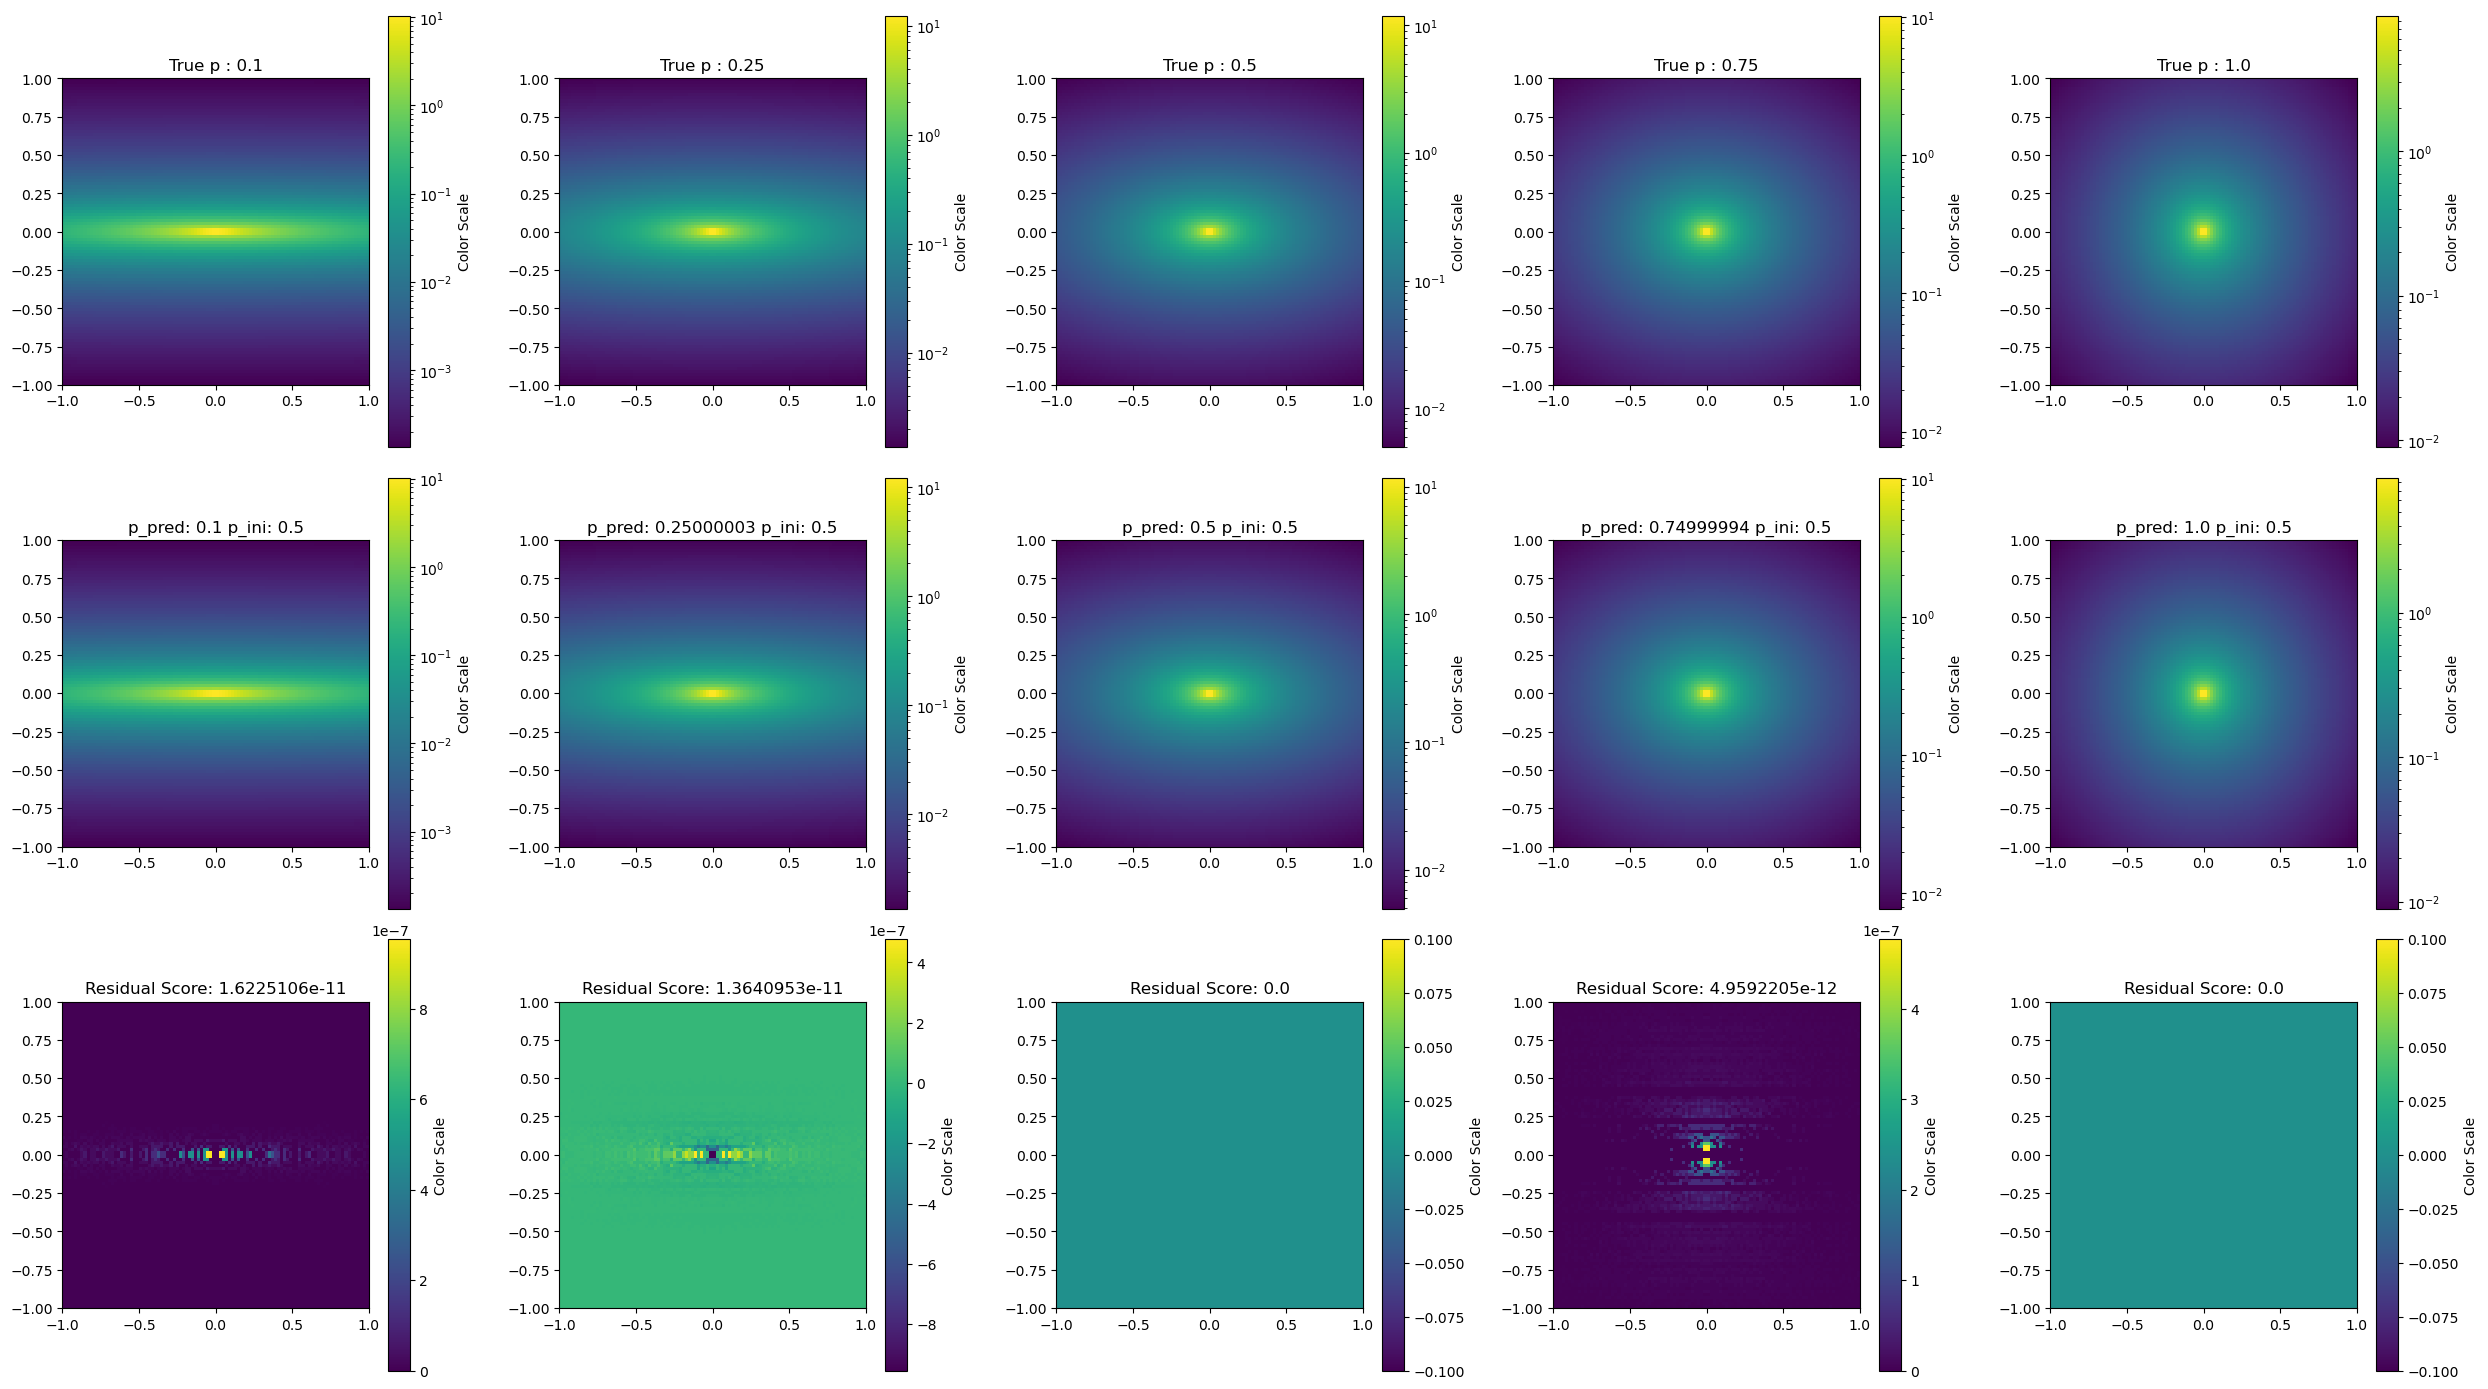

In [11]:
# varying over different p values

p = [0.1,0.25,0.5,0.75,1.]


# Set up the figure and subplots
fig, axes = plt.subplots(3,5, figsize=(25,14))

# Plot data in each subplot

for j in range(5):
    ax1 = axes[0, j]
    ax2 = axes[1, j]
    ax3 = axes[2, j]

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_def, p[j], q_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
    img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale')
    ax1.set_title("True p : "+str(p[j]))

    bounds = (p[0], p[-1])
    starting_guess = p_def #random.uniform(p[0], p[-1])
    initial_params = [e_def,starting_guess,q_def,rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def]
    optimize_mask = [False,True,False,False,False,False,False,False,False,False]
    pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,1,9,1.)
    print("Optimzer route: ",res)

    projected_pred_den = pred_den.project()
    img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale')
    ax2.set_title("p_pred: "+str(res[-1])+" p_ini: "+str(starting_guess))

    residual = sb_1.data - projected_pred_den.data
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale')
    ax3.set_title("Residual Score: "+str(score))


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()